# Scan-like threshold exploration

This notebook visualizes threshold-free, 60 s source-window observations for the M4 Human Gate. It does not classify traffic or select thresholds.

## 1. Load data

In [44]:
import math
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path("/Users/shunta/mawi-global-analysis")

csv_path = (
    repo_root
    / "results"
    / "202604081400"
    / "threshold_exploration"
    / "source_scan_windows.csv"
)

windows = pd.read_csv(csv_path)

broad_plot = windows.loc[
    (windows['syn_initiated_flow_count'] > 0)
    & (windows['unique_targets'] > 0)
]
broad_x_max = broad_plot['syn_initiated_flow_count'].max()
broad_y_max = broad_plot['unique_targets'].max()
broad_x_limits = (1, 10 ** math.ceil(math.log10(broad_x_max)))
broad_y_limits = (1, 10 ** math.ceil(math.log10(broad_y_max)))

print("rows:", len(windows))
print("sources:", windows["initial_syn_sender_ip"].nunique())

windows.head()

rows: 3458400
sources: 167223


,dataset,initial_syn_sender_ip,window_start,window_end,syn_initiated_flow_count,unique_targets,unique_dst_ips,unique_dst_ports,syn_to_rst_pattern_count,syn_synack_rst_pattern_count,high_confidence_probe_pattern_count,unique_high_confidence_targets,no_observed_response_count
0,202604081400,1.0.231.34,1.775625e+09,1.775625e+09,1,1,1,1,0,0,0,0,1
1,202604081400,1.0.231.34,1.775625e+09,1.775625e+09,1,1,1,1,0,0,0,0,1
2,202604081400,1.0.231.34,1.775625e+09,1.775625e+09,1,1,1,1,0,0,0,0,1
3,202604081400,1.0.231.34,1.775625e+09,1.775625e+09,1,1,1,1,0,0,0,0,1
4,202604081400,1.0.231.34,1.775625e+09,1.775625e+09,1,1,1,1,0,0,0,0,1


## 2. Broad Scan-like scatter

Each point is one source-window. Use this view to inspect bulk activity, the tail, isolated source-windows, and possible distribution breaks.

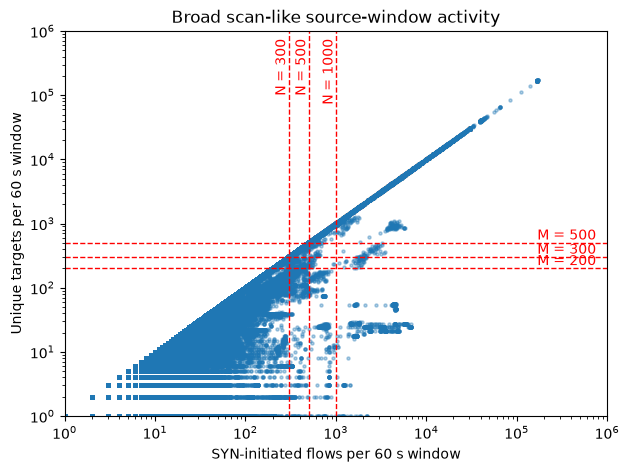

N=300, M=200: 56509 windows, 2388 sources
N=500, M=300: 22874 windows, 1723 sources
N=1000, M=500: 10437 windows, 246 sources


In [47]:
broad_candidates = [
    (300, 200),
    (500, 300),
    (1000, 500),
]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    windows['syn_initiated_flow_count'],
    windows['unique_targets'],
    alpha=0.35,
    s=5,
)
ax.set(
    xscale='log',
    yscale='log',
    xlim=broad_x_limits,
    ylim=broad_y_limits,
    xlabel='SYN-initiated flows per 60 s window',
    ylabel='Unique targets per 60 s window',
    title='Broad scan-like source-window activity',
)
for n, m in broad_candidates:
    ax.axvline(n, color='red', linestyle='--', linewidth=1)
    ax.axhline(m, color='red', linestyle='--', linewidth=1)
    ax.text(n, 0.98, f'N = {n}', color='red', rotation=90, transform=ax.get_xaxis_transform(), ha='right', va='top')
    ax.text(0.98, m, f'M = {m}', color='red', transform=ax.get_yaxis_transform(), ha='right', va='bottom')
plt.show()

for n, m in broad_candidates:
    matched = windows[
        (windows["syn_initiated_flow_count"] >= n)
        & (windows["unique_targets"] >= m)
    ]

    print(
        f"N={n}, M={m}: "
        f"{len(matched)} windows, "
        f"{matched['initial_syn_sender_ip'].nunique()} sources"
    )

## 3. Strict / High-confidence scatter

Each point is one source-window with positive values on both axes. `high_confidence_probe_pattern_count` is based on the positive observed TCP patterns `syn_to_rst` (not `sin_to_rst`) and `syn_synack_rst`, following the repository implementation.

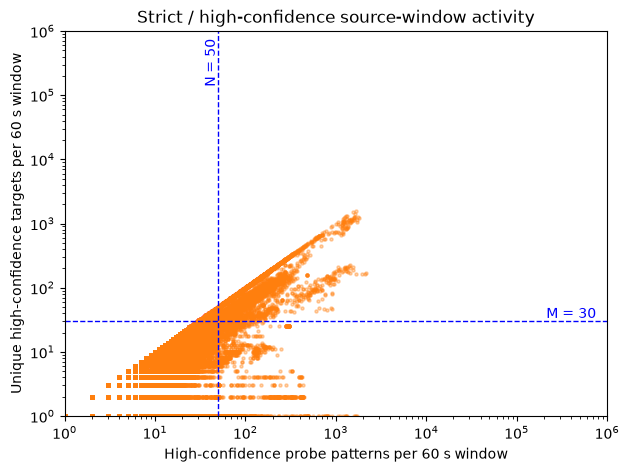

N=50, M=30: 5510 windows, 171 sources


In [ ]:
high_confidence = windows.loc[
    (windows['high_confidence_probe_pattern_count'] > 0)
    & (windows['unique_high_confidence_targets'] > 0)
].copy()

strict_candidates = [
    (50, 30),
    (100, 50),
    (200, 100),
]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    high_confidence['high_confidence_probe_pattern_count'],
    high_confidence['unique_high_confidence_targets'],
    alpha=0.35,
    color='tab:orange',
    s=5,
)
ax.set(
    xscale='log',
    yscale='log',
    xlim=broad_x_limits,
    ylim=broad_y_limits,
    xlabel='High-confidence probe patterns per 60 s window',
    ylabel='Unique high-confidence targets per 60 s window',
    title='Strict / high-confidence source-window activity',
)
for n, m in strict_candidates:
    ax.axvline(n, color='blue', linestyle='--', linewidth=1)
    ax.axhline(m, color='blue', linestyle='--', linewidth=1)
    ax.text(n, 0.98, f'N = {n}', color='blue', rotation=90, transform=ax.get_xaxis_transform(), ha='right', va='top')
    ax.text(0.98, m, f'M = {m}', color='blue', transform=ax.get_yaxis_transform(), ha='right', va='bottom')
plt.show()

for n, m in strict_candidates:
    matched = windows[
        (windows["high_confidence_probe_pattern_count"] >= n)
        & (windows["unique_high_confidence_targets"] >= m)
    ]

    print(
        f"N={n}, M={m}: "
        f"{len(matched)} windows, "
        f"{matched['initial_syn_sender_ip'].nunique()} sources"
    )

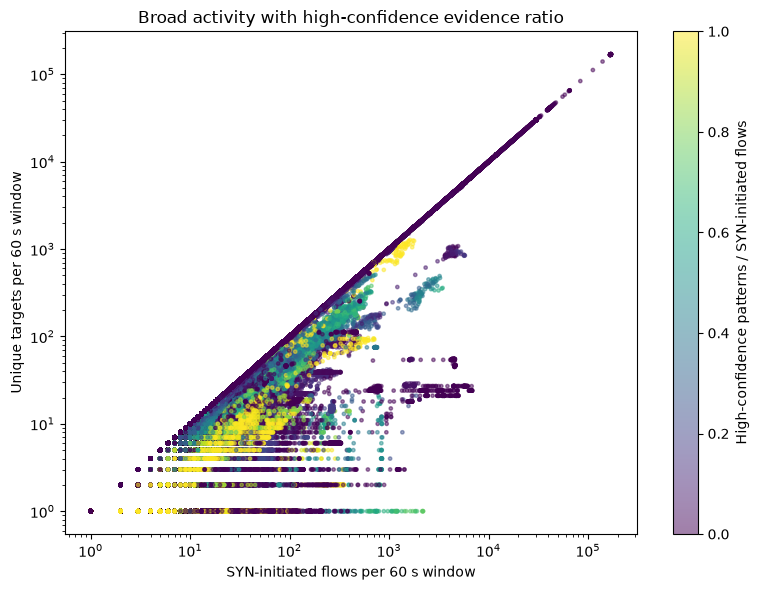

In [37]:
plot_df = windows.loc[
    (windows["syn_initiated_flow_count"] > 0)
    & (windows["unique_targets"] > 0)
].copy()

plot_df["high_confidence_ratio"] = (
    plot_df["high_confidence_probe_pattern_count"]
    / plot_df["syn_initiated_flow_count"]
)

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    plot_df["syn_initiated_flow_count"],
    plot_df["unique_targets"],
    c=plot_df["high_confidence_ratio"],
    s=6,
    alpha=0.5,
    cmap="viridis",
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("SYN-initiated flows per 60 s window")
ax.set_ylabel("Unique targets per 60 s window")
ax.set_title("Broad activity with high-confidence evidence ratio")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(
    "High-confidence patterns / SYN-initiated flows"
)

plt.tight_layout()
plt.show()